In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config_presets.tools.get_config import get_config


config = get_config('Daniel/VM_uncertainty')

endpoint_list = config['columns']['labels']

endpoint_list

['Dysphagia_M06']

In [184]:
df_DE_Xerostomia = pd.read_csv("/home/macraedc/rt_pred_results/Deep Ensemble/Xerostomia_ResNet/all_predictions.csv", sep=';')
df_MC_Xerostomia = pd.read_csv("/home/macraedc/rt_pred_results/MC Dropout/Xerostomia_ResNet_2mm_no_decay_higher_lr/model_1/all_predictions.csv", sep=';')
df_TTA_Xerostomia = pd.read_csv("/home/macraedc/rt_pred_results/TTA/Xerostomia_ResNet_2mm_no_decay_higher_lr/model_1/all_predictions.csv", sep=';')

df_DE_Dysphagia = pd.read_csv("/home/macraedc/rt_pred_results/Deep Ensemble/Dysphagia_ResNet_2mm_no_decay_higher_lr_2/all_predictions.csv", sep=';')
df_MC_Dysphagia = pd.read_csv("/home/macraedc/rt_pred_results/MC Dropout/Dysphagia_ResNet_2mm_no_decay_higher_lr/model_1/all_predictions.csv", sep=';')
df_TTA_Dysphagia = pd.read_csv("/home/macraedc/rt_pred_results/TTA/Dysphagia_ResNet_2mm_no_decay_higher_lr/model_1/all_predictions.csv", sep=';')

df_DE_OS = pd.read_csv("/home/macraedc/rt_pred_results/Deep Ensemble/Baoqiang_OS_2year/all_predictions.csv", sep=';')   # Baoqiang_OS_2year
df_MC_OS = pd.read_csv("/home/macraedc/rt_pred_results/MC Dropout/Baoqiang_OS_2year/model_1/all_predictions.csv", sep=';')
df_TTA_OS = pd.read_csv("/home/macraedc/rt_pred_results/TTA/Baoqiang_OS_2year/model_1/all_predictions.csv", sep=';')


df_DE_LRC = pd.read_csv("/home/macraedc/rt_pred_results/Deep Ensemble/Baoqiang_LRC_2year/all_predictions.csv", sep=';')
df_MC_LRC = pd.read_csv("/home/macraedc/rt_pred_results/MC Dropout/Baoqiang_LRC_2year/model_1/all_predictions.csv", sep=';')
df_TTA_LRC = pd.read_csv("/home/macraedc/rt_pred_results/TTA/Baoqiang_LRC_2year/model_1/all_predictions.csv", sep=';')

ALL_DFS_DICT = {
    "Xerostomia_M06": {
        "MC Dropout" : df_MC_Xerostomia,
        "Deep Ensemble": df_DE_Xerostomia,
        "TTA": df_TTA_Xerostomia
    },
    "Dysphagia_M06": {
        "MC Dropout": df_MC_Dysphagia,
        "Deep Ensemble": df_DE_Dysphagia,
        "TTA": df_TTA_Dysphagia
        },
    "OS_2year_censored" : {
        "MC Dropout": df_MC_OS,
        "Deep Ensemble": df_DE_OS,
        "TTA": df_TTA_OS
    },
    "LRC_2year_censored": {
        "MC Dropout": df_MC_LRC,
        "Deep Ensemble": df_DE_LRC,
        "TTA": df_TTA_LRC
    }
    
        
    
}

In [188]:
endpoints = ["Dysphagia_M06", "Xerostomia_M06"]
dropouts = ["05", "10", "15", "20", "25", "30", "35", "40", "45", "50"]
dropouts = ["05", "10", "15", "20", "25", "30", "35", "40", "45", "50"]
dropouts = ['30']

DF_metrics = pd.DataFrame()

#ALL_DFS_DICT = {}

for endpoint in endpoints:

    #ALL_DFS_DICT[endpoint] = {}

    for dropout in dropouts:
        endpoint_name = endpoint.split("_")[0]
        
        all_preds_dir = f"/home/macraedc/rt_pred_results/MC_Dropout/{endpoint_name}_{dropout}/model_1/all_predictions.csv"
        df_preds = pd.read_csv(all_preds_dir, sep=';')

        ALL_DFS_DICT[endpoint][f"MC Dropout {dropout}"] = df_preds

        metrics_dir = f"/home/macraedc/rt_pred_results/MC_Dropout/{endpoint_name}_{dropout}/model_1/test_metrics.csv"
        df_metrics = pd.read_csv(metrics_dir, sep=';', index_col=0)
        df_metrics = df_metrics[endpoint].to_dict()
        df_metrics['Endpoint'] = endpoint
        df_metrics['Dropout'] = dropout

        df_metrics = pd.DataFrame(df_metrics, index=[0])

        DF_metrics = pd.concat([DF_metrics, df_metrics], ignore_index=True)

        

In [140]:
import seaborn as sns

import matplotlib.pyplot as plt

sns.barplot(data=DF_metrics, x='Dropout', y='AUC', hue='Endpoint')
plt.title('MC Dropout AUC by Endpoint and Dropout Rate')
plt.show()

sns.barplot(data=DF_metrics, x='Dropout', y='ECE', hue='Endpoint')
plt.title('MC Dropout ECE by Endpoint and Dropout Rate')
plt.show()

sns.barplot(data=DF_metrics, x='Dropout', y='ACE', hue='Endpoint')
plt.title('MC Dropout AUC by Endpoint and Dropout Rate')
plt.show()

ModuleNotFoundError: No module named 'seaborn'

In [185]:
%load_ext autoreload
%autoreload 2

from src.uncertainty.metrics.mutual_information import mutual_information
from src.uncertainty.metrics.entropy import binary_entropy
from src.uncertainty.metrics.variance import variance

# label_columns = [x + '_true' for x in endpoint_list]
# pred_columns = [col for col in df_MC_Xerostomia.columns if 'pred' in col]
# pred_columns_dict = {endpoint: [col for col in df_MC_Xerostomia.columns if endpoint+"_pred" in col] for endpoint in endpoint_list}

UQ_RESULTS_DICT = {
    "Xerostomia_M06" : {},
    "Dysphagia_M06": {},
    "OS_2year_censored": {},
    "LRC_2year_censored": {}
                   }

ENDPOINT_TYPES = {
    "Xerostomia_M06": "Binary",
    "Dysphagia_M06": "Binary",
    "OS_2year_censored": "Binary",
    "LRC_2year_censored": "Binary"
    #"OS_2year_no_clinical": "Binary"
    
}


def compute_uncertainty_metrics_for_endpoint(df, endpoint):
#for endpoint in endpoint_list:
    df_UQ_results = pd.DataFrame(index=df.index)

    #label_columns = [x + '_true' for x in endpoint_list]
    endpoint_pred_columns = [col for col in df.columns if 'pred' in col]

    all_endpoint_preds = df[endpoint_pred_columns]
    #all_endpoint_preds = (all_endpoint_preds - all_endpoint_preds.min().min()) / (all_endpoint_preds.max().max() - all_endpoint_preds.min().min())
    mean_endpoint_preds = all_endpoint_preds.mean(axis=1)

    # if endpoint == "OS":
    #     plt.hist(mean_endpoint_preds, bins=50, alpha=0.3)

    df_UQ_results['Mean Prediction'] = mean_endpoint_preds

    if ENDPOINT_TYPES[endpoint] == "Binary":
        df_UQ_results['True Labels'] = df[endpoint + '_true']
    else:
        df_UQ_results['True Label Event'] = df[endpoint + '_event_true'].values
        df_UQ_results['True Months Event'] = df[endpoint + '_months_true'].values
        
    df_UQ_results['Mutual Information'] = mutual_information(all_endpoint_preds)
    df_UQ_results['Binary Entropy'] = binary_entropy(mean_endpoint_preds)
    df_UQ_results['Variance'] =  variance(all_endpoint_preds)

    return df_UQ_results



for endpoint, dfs in ALL_DFS_DICT.items():
    
    #pred_columns_dict = {endpoint: [col for col in df_MC_Xerostomia.columns if endpoint+"_pred" in col] for endpoint in endpoint_list}

    for method, df_all_preds in dfs.items():
        # label_columns = [x + '_true' for x in endpoint_list]
        # pred_columns = [col for col in dfs.columns if 'pred' in col]

        df_UQ_results = compute_uncertainty_metrics_for_endpoint(df_all_preds, endpoint)
        UQ_RESULTS_DICT[endpoint][method] = df_UQ_results


UQ_methods_list = list(ALL_DFS_DICT["Dysphagia_M06"].keys()) 
UQ_metrics_list = ["Binary Entropy", "Variance", "Mutual Information"]

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


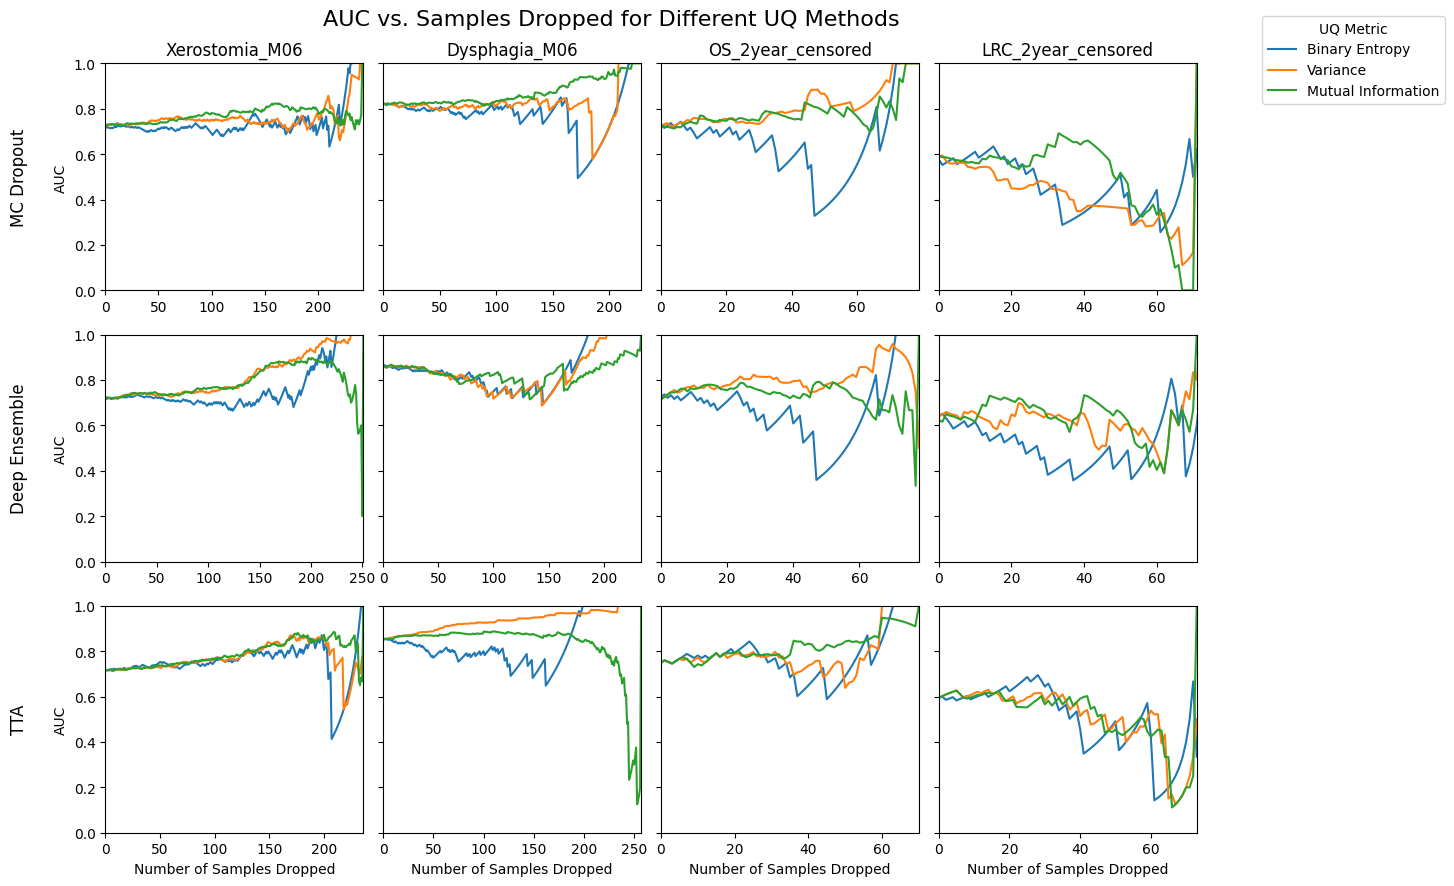

In [186]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from lifelines.utils import concordance_index


endpoint_list = list(UQ_RESULTS_DICT.keys())

n_endpoints = len(endpoint_list)
n_methods = len(UQ_methods_list)
n_metrics = len(UQ_metrics_list)

fig, axes = plt.subplots(n_methods, n_endpoints, figsize=(3*len(endpoint_list), 3 * len(UQ_methods_list)), sharey=True, sharex=False)



def compute_s_auc(fractions_dropped, aucs, normalize=True):
    """
    Compute sparsification AUC (s-AUC).
    Parameters:
    - fractions_dropped: list or array of fractions of data removed (e.g., [0.0, 0.05, ..., 0.9])
    - aucs: list or array of AUCs computed after each fraction dropped
    - normalize: if True, normalize by the max possible area (so s-AUC is between 0 and 1)
    Returns:
    - s-AUC value (float)
    """
    assert len(fractions_dropped) == len(aucs), "Arrays must be same length"
    area = np.trapz(aucs, x=fractions_dropped)
    
    if normalize:
        max_area = np.trapz([1.0] * len(aucs), x=fractions_dropped)
        return area / max_area
    
    return area


for col_idx, endpoint in enumerate(endpoint_list):
    #for col_idx, (ax, UQ_metric_name) in enumerate(zip(row, UQ_metrics_list)):
    for row_idx, UQ_method_name in enumerate( UQ_methods_list):

        # Robustly get the correct axis for any shape of axes
        if n_endpoints == 1 and n_methods == 1:
            ax = axes
        elif n_endpoints == 1:
            ax = axes[col_idx]
        elif n_methods == 1:
            ax = axes[row_idx]
        else:
            ax = axes[row_idx, col_idx]

        if row_idx == 0:
            ax.set_title(endpoint)
        
        if row_idx == n_methods - 1:
            ax.set_xlabel("Number of Samples Dropped")
        if col_idx == 0:
            ax.set_ylabel("AUC" if ENDPOINT_TYPES[endpoint] == "Binary" else "C-Index")
            # Annotate the endpoint name to the left of each row
            ax.annotate(UQ_method_name, xy=(-0.3, 0.5), xycoords='axes fraction',
                ha='right', va='center', fontsize=12, rotation=90)

        try:
            df_UQ_temp = UQ_RESULTS_DICT[endpoint][UQ_method_name].copy()
        except KeyError:
            print(f"Warning: No data for endpoint '{endpoint}' and UQ method '{UQ_method_name}'. Skipping this plot.")
            continue

        
        for UQ_metric_name in UQ_metrics_list:

            if ENDPOINT_TYPES[endpoint] == "Binary":
                df_UQ_no_missing_labels = df_UQ_temp[df_UQ_temp['True Labels'] != -1]

                labels_iter = df_UQ_no_missing_labels['True Labels'].copy()
            else:
                df_UQ_no_missing_labels = df_UQ_temp[df_UQ_temp['True Label Event'] != -1]
                # For event-based endpoints, we use the True Label Event and True Months Event
                labels_iter = df_UQ_no_missing_labels['True Label Event'].copy()
                months_iter = df_UQ_no_missing_labels['True Months Event'].copy()

                labels_iter = np.stack([labels_iter.values, months_iter.values], axis=1)

                #print(df_UQ_no_missing_labels)

            mean_preds_iter = df_UQ_no_missing_labels['Mean Prediction'].copy()

            UQ_metric_iter = df_UQ_no_missing_labels[UQ_metric_name].copy()
            indices = np.arange(len(mean_preds_iter))
            all_metric_values = []

            #print(endpoint, UQ_method_name, roc_auc_score(labels_iter, mean_preds_iter))

            while np.unique(labels_iter).size >= 2:
                max_idx = np.argmax(UQ_metric_iter)
                mean_preds_iter = np.delete(mean_preds_iter, max_idx, axis=0)
                labels_iter = np.delete(labels_iter, max_idx, axis=0)
                UQ_metric_iter = np.delete(UQ_metric_iter, max_idx, axis=0)
                indices = np.delete(indices, max_idx, axis=0)
                
                if ENDPOINT_TYPES[endpoint] == "Binary":
                    if np.unique(labels_iter).size == 2:
                        metric_value = roc_auc_score(labels_iter, mean_preds_iter)
                    else:
                        metric_value = 1
                else:
                    
                    if np.unique(labels_iter[:, 0]).size == 2:
                        metric_value = concordance_index(labels_iter[:, 1], mean_preds_iter, labels_iter[:, 0])
                    #auc = roc_auc_score(labels_iter, mean_preds_iter)
                    else:
                        metric_value = 1
                all_metric_values.append(metric_value)


            ax.plot(all_metric_values, label=UQ_metric_name)
            ax.set_xlim(0, len(all_metric_values) - 1)
            ax.set_ylim(0, 1.0)

            # x = compute_s_auc(np.linspace(0, 1, len(all_metric_values)), all_metric_values)
            # print(x)
        if row_idx == 0 and col_idx == 0:
            fig.legend(title="UQ Metric", loc='upper right', bbox_to_anchor=(1.2, 0.98))

        # if row_idx == 0 and col_idx == 0:
        #         ax.legend(title="UQ Metric", loc='upper left')


plt.suptitle("AUC vs. Samples Dropped for Different UQ Methods", fontsize=16)
plt.tight_layout()
plt.show()

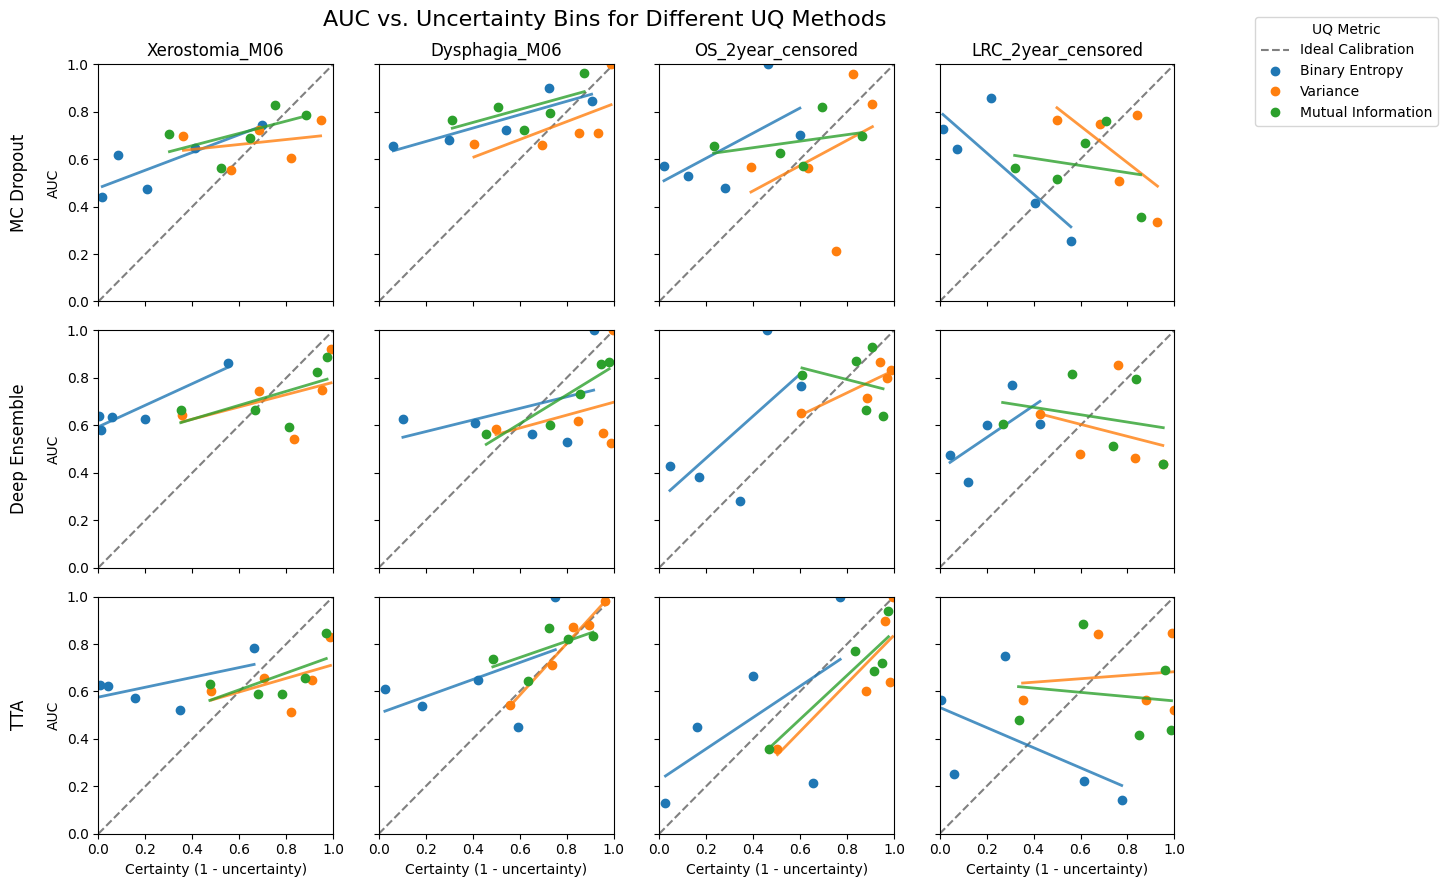

In [187]:
from src.evaluation.metrics.classification import accuracy
from sklearn.calibration import calibration_curve

colours = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan']
colours_dict = {UQ_metric_name: colour for UQ_metric_name, colour in zip(UQ_metrics_list, colours)}

fig, axes = plt.subplots(n_methods, n_endpoints, figsize=(3 * n_endpoints, 3 * n_methods), sharey=True, sharex=True)

for col_idx, endpoint in enumerate(endpoint_list):
    for row_idx, UQ_method_name in enumerate(UQ_methods_list):

        # Robustly get the correct axis for any shape of axes
        if n_endpoints == 1 and n_methods == 1:
            ax = axes
        elif n_endpoints == 1:
            ax = axes[col_idx]
        elif n_methods == 1:
            ax = axes[row_idx]
        else:
            ax = axes[row_idx, col_idx]

        # plot the ideal line here
        ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Ideal Calibration')
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)

        try:
            df_UQ_temp = UQ_RESULTS_DICT[endpoint][UQ_method_name]
        except KeyError:
            print(f"Warning: No data for endpoint '{endpoint}' and UQ method '{UQ_method_name}'. Skipping this plot.")
            continue

        
        if ENDPOINT_TYPES[endpoint] == "Binary":
            df_UQ_no_missing_labels = df_UQ_temp[df_UQ_temp['True Labels'] != -1]
            true_labels = df_UQ_no_missing_labels['True Labels'].values
        else:
            df_UQ_no_missing_labels = df_UQ_temp[df_UQ_temp['True Label Event'] != -1]
            # For event-based endpoints, we use the True Label Event and True Months Event
            true_labels = df_UQ_no_missing_labels[['True Label Event', 'True Months Event']].values
            
        mean_preds = df_UQ_no_missing_labels['Mean Prediction'].values
        
        N_bins = 5  # Number of bins for uncertainty metric

        for UQ_metric_name in UQ_metrics_list:
            UQ_metric = df_UQ_no_missing_labels[UQ_metric_name].values
            # Normalize the UQ metric to [0, 1] using min-max normalization
            
            if UQ_metric_name == "Binary Entropy":
                UQ_metric_norm = UQ_metric  # binary entropy is already in [0, 1]
            else:  
                UQ_metric_norm = (UQ_metric - np.min(UQ_metric)) / (np.max(UQ_metric) - np.min(UQ_metric)) # min-max normalization

            # Bin the UQ metric into 10 bins
            binning_method = "quantile"

            if binning_method == "quantile":
                uq_bins = pd.qcut(UQ_metric_norm, N_bins, labels=False, duplicates='drop')
            elif binning_method == "uniform":
                uq_bins = pd.cut(UQ_metric_norm, N_bins, labels=False, include_lowest=True, duplicates='drop')
            else:
                raise ValueError(f"Unknown binning_method: {binning_method}")
            aucs = []
            bin_centers = []

            for b in np.unique(uq_bins):
                #print(b)
                idx = uq_bins == b
                # Only calculate AUC if both classes are present in the bin
                if ENDPOINT_TYPES[endpoint] == "Binary": 
                    if np.unique(true_labels[idx]).size == 2:
                        auc = roc_auc_score(true_labels[idx], mean_preds[idx])
                        #auc = accuracy(config, true_labels[idx], mean_preds[idx])
                        aucs.append(auc)
                    else:
                        aucs.append(1)   # all labels in the bin are the same, so AUC is 1
                else:
                    if np.unique(true_labels[idx][:, 0]).size == 2:
                        auc = concordance_index(true_labels[idx][:, 1], mean_preds[idx], true_labels[idx][:, 0])
                        #auc = roc_auc_score(true_labels[idx], mean_preds[idx])
                        aucs.append(auc)
                    else:
                        aucs.append(1)
                
                bin_centers.append(1 - UQ_metric_norm[idx].mean())

            shape = 'o'
            ax.plot(bin_centers, aucs, shape, label=UQ_metric_name, color=colours_dict[UQ_metric_name])

            # plot the best-fit line
            coef = np.polyfit(bin_centers, aucs, 1)
            linear_fit = np.poly1d(coef)
            ax.plot(bin_centers, linear_fit(bin_centers), linestyle='-', color=colours_dict[UQ_metric_name], alpha=0.8, linewidth=2)



        if row_idx == 0:
            ax.set_title(endpoint)
        if row_idx == n_methods - 1:
            ax.set_xlabel("Certainty (1 - uncertainty)")
            
        if row_idx == 0 and col_idx == 0:
            fig.legend(title="UQ Metric", loc='upper right', bbox_to_anchor=(1.2, 0.98))

        # Annotate the endpoint name to the left of each row
        if col_idx == 0:
            ax.set_ylabel("AUC")
            ax.annotate(UQ_method_name, xy=(-0.3, 0.5), xycoords='axes fraction',
                        ha='right', va='center', fontsize=12, rotation=90)

plt.suptitle("AUC vs. Uncertainty Bins for Different UQ Methods", fontsize=16)
plt.tight_layout()
plt.show()

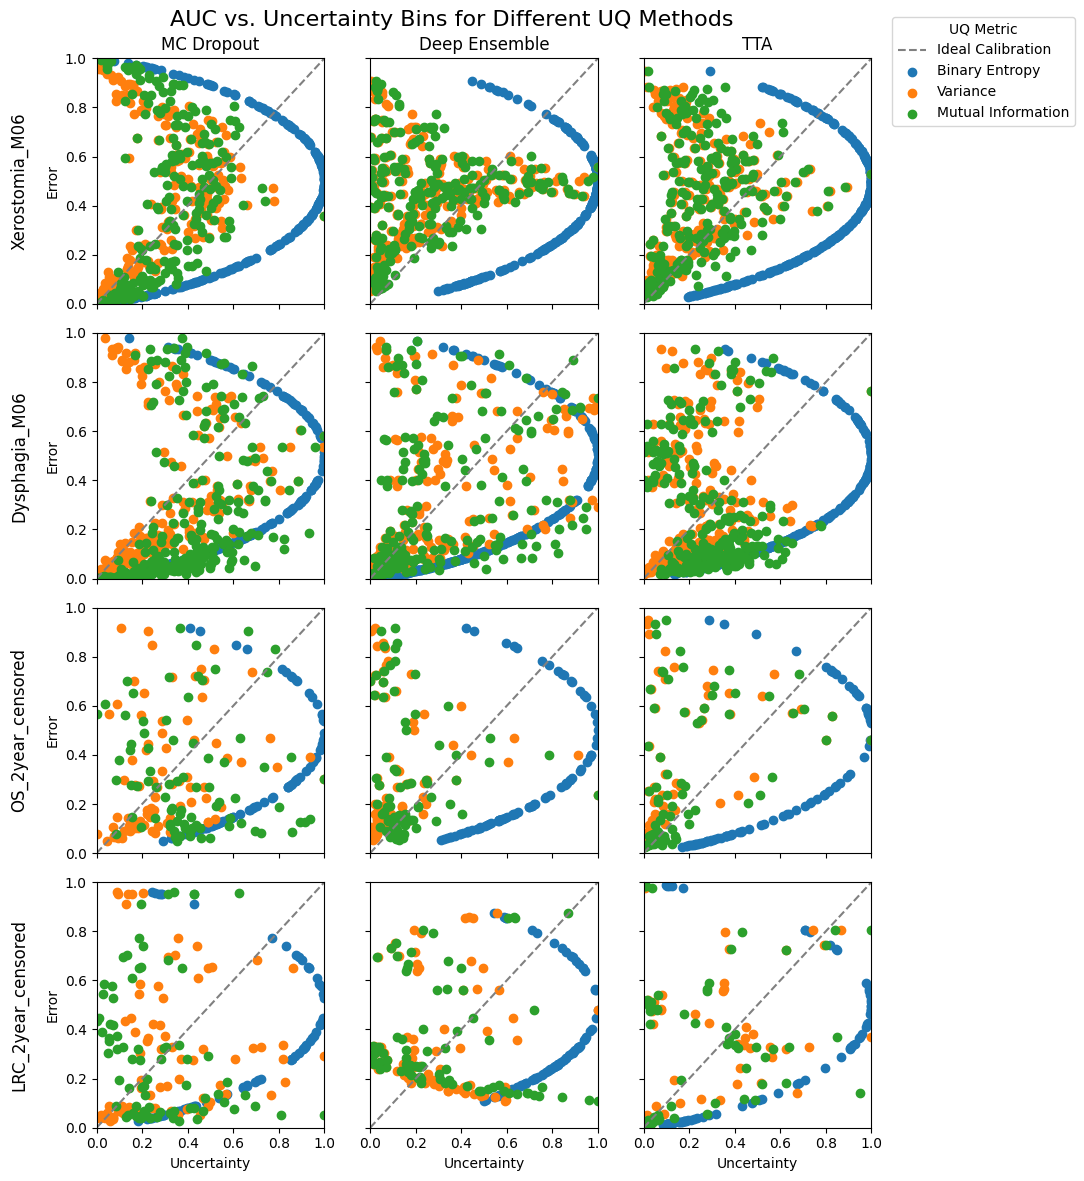

In [156]:
from src.evaluation.metrics.classification import accuracy
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(n_endpoints, n_methods, figsize=(3 * n_methods, 3 * n_endpoints), sharey=True, sharex=True)

for row_idx, endpoint in enumerate(endpoint_list):
    for col_idx, UQ_method_name in enumerate(UQ_methods_list):

        # Robustly get the correct axis for any shape of axes
        if n_endpoints == 1 and n_methods == 1:
            ax = axes
        elif n_endpoints == 1:
            ax = axes[col_idx]
        elif n_methods == 1:
            ax = axes[row_idx]
        else:
            ax = axes[row_idx, col_idx]

        # plot the ideal line here
        ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Ideal Calibration')
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)

        try:
            df_UQ_temp = UQ_RESULTS_DICT[endpoint][UQ_method_name]
        except KeyError:
            print(f"Warning: No data for endpoint '{endpoint}' and UQ method '{UQ_method_name}'. Skipping this plot.")
            continue

        
        if ENDPOINT_TYPES[endpoint] == "Binary":
            df_UQ_no_missing_labels = df_UQ_temp[df_UQ_temp['True Labels'] != -1]
            true_labels = df_UQ_no_missing_labels['True Labels'].values
        else:
            df_UQ_no_missing_labels = df_UQ_temp[df_UQ_temp['True Label Event'] != -1]
            # For event-based endpoints, we use the True Label Event and True Months Event
            true_labels = df_UQ_no_missing_labels[['True Label Event', 'True Months Event']].values
            
        mean_preds = df_UQ_no_missing_labels['Mean Prediction'].values
        
        N_bins = 5  # Number of bins for uncertainty metric

        for UQ_metric_name in UQ_metrics_list:
            UQ_metric = df_UQ_no_missing_labels[UQ_metric_name].values
            # Normalize the UQ metric to [0, 1] using min-max normalization
            
            if UQ_metric_name == "Binary Entropy":
                UQ_metric_norm = UQ_metric  # binary entropy is already in [0, 1]
            else:  
                UQ_metric_norm = (UQ_metric - np.min(UQ_metric)) / (np.max(UQ_metric) - np.min(UQ_metric)) # min-max normalization
                #UQ_metric_norm = UQ_metric

            error = abs(mean_preds - true_labels)

            ax.scatter(UQ_metric_norm, error, marker='o', label=UQ_metric_name)


        if row_idx == 0:
            ax.set_title(UQ_method_name)
        if row_idx == n_endpoints - 1:
            ax.set_xlabel("Uncertainty")
            
        if row_idx == 0 and col_idx == 0:
            fig.legend(title="UQ Metric", loc='upper right', bbox_to_anchor=(1.2, 0.98))

        # Annotate the endpoint name to the left of each row
        if col_idx == 0:
            ax.set_ylabel("Error")
            ax.annotate(endpoint, xy=(-0.3, 0.5), xycoords='axes fraction',
                        ha='right', va='center', fontsize=12, rotation=90)

plt.suptitle("AUC vs. Uncertainty Bins for Different UQ Methods", fontsize=16)
plt.tight_layout()
plt.show()